# 08｜Virtual Metrology — Group-Aware Predictive Modeling

## 這一本要回答的問題

07 已經把 Raw process trace 整理成 wafer-level features。  
到了 08，我要做的是 **Mean Si Etch 的 Virtual Metrology model**。

但我不想看一個「把同一個 Lot 的 wafers 隨機拆進 train / test」後得到的漂亮分數，因為同一 Lot 裡的 wafers 本來就可能很像。

所以這一本真正想回答的是：

> **如果整個 Lot 都沒有出現在 training data 裡，只靠前面建立的 process features，模型還能不能預測這個 held-out Lot 的 `mean_si_etch`？**

因此我把 `lot_number` 當作 group，使用 **Leave-One-Lot-Out outer validation**。

這一版只建 `mean_si_etch`，不另外同時建 `cv_si_etch_pct`，因為目前只有 88 片 labeled wafers。我先把一個 target 的 validation 做乾淨，再考慮其他 targets。


## 1. Modeling 怎麼設計？

這裡使用兩層 group-aware validation。

### Outer loop：Leave-One-Lot-Out

每一次完整留一個 Lot 當 test。  
這個 test Lot 不會參與：

- near-constant feature filtering
- scaling
- feature-set selection
- hyperparameter selection
- model selection

### Inner loop：3-Fold GroupKFold

只在剩下的 outer-training Lots 裡比較 candidates。

這次測試的 model families 有：

- Ridge
- ElasticNet
- PLS Regression
- RBF-SVR

Feature sets 則比較：

- Base
- Extended

07 雖然有做 full-data near-constant diagnostic，但那只是觀察用。  
08 會在每一個 training fold 裡重新做：

`Fold-local Near-Constant Filter → StandardScaler → Model`

也就是所有需要 `fit()` 的 preprocessing 都只看 training data。

另外我保留兩個很簡單的 baseline：

1. Training-Mean baseline
2. Wafer-Sequence-Only linear baseline

第二個 baseline 故意只用 `wafer_number`，不是正式 deployment model，而是讓我知道：如果 process model 表現很好，它至少要和一個已知有很強 sequence structure 的簡單模型比較。


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR


pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 200)

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

base_path = PROCESSED_DATA_DIR / "07_modeling_dataset_base.csv"
extended_path = PROCESSED_DATA_DIR / "07_modeling_dataset_extended.csv"

for path in [base_path, extended_path]:
    print(f"{path.name:<42}", "存在" if path.exists() else "找不到")

if not base_path.exists() or not extended_path.exists():
    raise FileNotFoundError("缺少 07 的 Modeling Dataset，請先完成 07_feature_engineering。")


class RelativeToleranceFeatureFilter(BaseEstimator, TransformerMixin):
    """Fold-local near-constant filter using np.allclose-like tolerance.

    A feature is removed when every training value is close to the first
    training value under: atol + rtol * |reference|.
    The held-out fold never participates in this decision.
    """

    def __init__(self, rtol=1e-7, atol=1e-8):
        self.rtol = rtol
        self.atol = atol

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        if X.ndim != 2:
            raise ValueError("X 必須是 2D matrix")
        if X.shape[0] == 0 or X.shape[1] == 0:
            raise ValueError("X 不可為空")
        if not np.isfinite(X).all():
            raise ValueError("Near-constant filter 收到 NaN / Inf")

        reference = X[0]
        tolerance = self.atol + self.rtol * np.abs(reference)
        max_deviation = np.max(np.abs(X - reference), axis=0)

        self.support_ = max_deviation > tolerance
        self.n_features_in_ = X.shape[1]

        if not self.support_.any():
            raise ValueError("Training fold 的所有 predictors 都被判定為 near-constant")

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return X[:, self.support_]

    def get_support(self, indices=False):
        if not hasattr(self, "support_"):
            raise ValueError("Filter 尚未 fit")
        if indices:
            return np.flatnonzero(self.support_)
        return self.support_.copy()


07_modeling_dataset_base.csv               存在
07_modeling_dataset_extended.csv           存在


### 1.1 上游資料有沒有準備好？

Base 和 Extended 兩個 modeling CSV 都有成功找到。

所以 08 可以直接接 07 的結果，不需要回去重新做 feature engineering。  
這也代表後面 Base / Extended 的欄位定義會沿用 07，不在這一本臨時改另一套。

## 2. 載入 Modeling Dataset，先確認樣本、Lots 和 Target

接下來把 Base / Extended 兩張表讀進來，先檢查兩邊的 wafer metadata、target、predictor 數和 missing values 是否一致。

這一步還沒有建模型，主要是先確認 08 接到的是同一批 **88 片 labeled wafers**，而且 Base / Extended 只是 feature set 不同，不是樣本母體不同。


In [2]:
base_df = pd.read_csv(base_path)
extended_df = pd.read_csv(extended_path)

metadata_columns = [
    "experiment_key",
    "lot_number",
    "wafer_number",
]

target_columns = [
    "mean_si_etch",
    "cv_si_etch_pct",
    "std_si_etch",
    "range_si_etch",
    "p90_width_si_etch",
]

base_predictors = [
    column
    for column in base_df.columns
    if column not in metadata_columns + target_columns
]

extended_predictors = [
    column
    for column in extended_df.columns
    if column not in metadata_columns + target_columns
]

if not base_df[metadata_columns].equals(extended_df[metadata_columns]):
    raise ValueError("Base / Extended 的 Wafer Metadata 順序不一致")

if not np.allclose(base_df["mean_si_etch"], extended_df["mean_si_etch"]):
    raise ValueError("Base / Extended 的 Target 不一致")

if base_df["experiment_key"].duplicated().any():
    raise ValueError("Base Dataset 出現重複 experiment_key")

if extended_df["experiment_key"].duplicated().any():
    raise ValueError("Extended Dataset 出現重複 experiment_key")

assert len(base_df) == 88
assert len(extended_df) == 88
assert base_df["lot_number"].nunique() == 10
assert len(base_predictors) == 82
assert len(extended_predictors) == 109
assert not base_df[base_predictors].isna().any().any()
assert not extended_df[extended_predictors].isna().any().any()
assert not base_df["mean_si_etch"].isna().any()

print("Labeled Wafers：", len(base_df))
print("Lots：", base_df["lot_number"].nunique())
print("Base Predictors：", len(base_predictors))
print("Extended Predictors：", len(extended_predictors))
print("Base Missing：", int(base_df[base_predictors].isna().sum().sum()))
print("Extended Missing：", int(extended_df[extended_predictors].isna().sum().sum()))
print("Target Missing：", int(base_df["mean_si_etch"].isna().sum()))

print("\nLabeled Wafers by Lot：")
display(
    base_df.groupby("lot_number").size().rename("n_wafers").reset_index()
)

print("\nMean Si Etch Summary：")
display(base_df["mean_si_etch"].describe())


Labeled Wafers： 88
Lots： 10
Base Predictors： 82
Extended Predictors： 109
Base Missing： 0
Extended Missing： 0
Target Missing： 0

Labeled Wafers by Lot：


,lot_number,n_wafers
0,1,9
1,2,10
2,3,10
3,4,10
4,5,10
5,6,10
6,7,6
7,8,10
8,9,9
9,10,4



Mean Si Etch Summary：


count    88.000000
mean     43.668120
std       0.401909
min      42.942928
25%      43.349077
50%      43.667601
75%      43.983902
max      44.376304
Name: mean_si_etch, dtype: float64

### 2.1 Modeling data 目前長什麼樣？

這次真正有 Quality label、可以拿來做 supervised modeling 的資料是：

- **88 片 wafers**
- **10 個 Lots**
- Base：**82 predictors**
- Extended：**109 predictors**
- predictors 和 target 都沒有 missing value

各 Lot 的 labeled wafers 介於 **4～10 片**，不是完全平衡。

`mean_si_etch` 的分布是：

- Mean：**43.6681 µm**
- Std：**0.4019 µm**
- Min：**42.9429 µm**
- Max：**44.3763 µm**

所以這是一個很典型的小樣本、高維、又有 group structure 的問題。  
後面不能只看 pooled score，因為某一個樣本少的 Lot 如果特別難預測，平均值可能會把它藏掉。


## 3. 建立 X / y / groups，先做欄位層級的 Leakage Check

正式 process model 不放：

- `lot_number`
- `wafer_number`
- `experiment_key`
- Quality target

其中：

- `lot_number` 只拿來分 group；
- `wafer_number` 只用在 sequence-only baseline；
- 正式 model 只吃 07 定義的 process predictors。

這一步先檢查欄位名稱，確認最直接的 target / ID leakage 沒有混進來。


In [3]:
X_sets = {
    "Base": base_df[base_predictors].to_numpy(dtype=float),
    "Extended": extended_df[extended_predictors].to_numpy(dtype=float),
}

predictor_names = {
    "Base": base_predictors,
    "Extended": extended_predictors,
}

y = base_df["mean_si_etch"].to_numpy(dtype=float)
groups = base_df["lot_number"].to_numpy(dtype=int)
wafer_number = base_df["wafer_number"].to_numpy(dtype=float)
experiment_keys = base_df["experiment_key"].to_numpy()

forbidden = {
    "experiment_key",
    "lot_number",
    "wafer_number",
    "mean_si_etch",
    "cv_si_etch_pct",
    "std_si_etch",
    "range_si_etch",
    "p90_width_si_etch",
}

for name, columns in predictor_names.items():
    overlap = sorted(set(columns) & forbidden)
    print(name, "Forbidden Overlap：", overlap)
    assert len(overlap) == 0

print("Group Count：", len(np.unique(groups)))
print("Column-Level Leakage Guard：通過")


Base Forbidden Overlap： []
Extended Forbidden Overlap： []
Group Count： 10
Column-Level Leakage Guard：通過


### 3.1 Leakage Guard 結果

Base 和 Extended 的 forbidden overlap 都是：

`[]`

而且 group count = **10**。

所以 predictor matrix 裡沒有直接放入 ID、Lot、wafer number 或 Quality target。

這只代表「欄位層級」沒有明顯 leakage。  
後面真正重要的是 near-constant filter、scaler 和 model 都必須在每個 training fold 裡 fit；這部分會由 Pipeline 和 nested CV 處理。


## 4. 先建立兩個簡單 Baselines

在看比較複雜的 model 前，先用兩個很簡單的方法當參考。

### Training-Mean Baseline

每個 held-out Lot 都只預測 outer-training wafers 的平均 `mean_si_etch`。

這可以看成「完全不知道 process，只猜 training 平均」。

### Sequence-Only Baseline

只用 `wafer_number` 建 linear regression，而且每個 outer fold 都只用 training Lots fit。

這不是正式 process model。  
它只是讓我知道，單靠 wafer sequence 這個很簡單的資訊，本身已經能做到什麼程度。


In [4]:
outer_cv = LeaveOneGroupOut()
outer_splits = list(outer_cv.split(np.zeros(len(y)), y, groups))

mean_baseline_pred = np.full(len(y), np.nan)
sequence_baseline_pred = np.full(len(y), np.nan)

for train_idx, test_idx in outer_splits:
    y_train = y[train_idx]

    mean_baseline_pred[test_idx] = y_train.mean()

    sequence_model = LinearRegression()
    sequence_model.fit(
        wafer_number[train_idx].reshape(-1, 1),
        y_train,
    )
    sequence_baseline_pred[test_idx] = sequence_model.predict(
        wafer_number[test_idx].reshape(-1, 1)
    )


def regression_metrics(actual, predicted):
    return {
        "rmse": float(mean_squared_error(actual, predicted) ** 0.5),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }

baseline_metrics = pd.DataFrame(
    [
        {"model": "Training-Mean Baseline", **regression_metrics(y, mean_baseline_pred)},
        {"model": "Sequence-Only Linear Baseline", **regression_metrics(y, sequence_baseline_pred)},
    ]
)

display(baseline_metrics.round(4))


,model,rmse,mae,r2
0,Training-Mean Baseline,0.4044,0.3477,-0.0239
1,Sequence-Only Linear Baseline,0.2209,0.1833,0.6944


### 4.1 Baseline 結果怎麼看？

Training-Mean baseline：

- RMSE = **0.4044 µm**
- MAE = **0.3477 µm**
- R² = **-0.0239**

R² 接近 0 而且略為負值，代表只猜 training mean 幾乎沒有辦法解釋 wafer-to-wafer variation。

Sequence-only baseline：

- RMSE = **0.2209 µm**
- MAE = **0.1833 µm**
- R² = **0.6944**

相較 mean baseline，RMSE 大約降低 **45.4%**。  
這和前面幾本看到的 sequence structure 是一致的：`wafer_number` 雖然不是 process sensor，但對 target 本身確實有很強的 predictive pattern。

所以後面的 process model 不應只跟 mean baseline 比。  
更有意義的是看它在同樣的 held-out-Lot setup 下，能不能也低於 **0.2209 µm** 的 sequence-only baseline。

不過就算 process model 勝過 sequence baseline，也只能說它的 process features 在這個 evaluation 裡表現更好；因為 process features 本身也可能帶有 sequence-related pattern，不能直接說已經證明「process 提供了完全獨立於 sequence 的額外因果資訊」。


## 5. 建立 Candidate Pipelines

因為只有 88 片 labeled wafers，我沒有做超大的 hyperparameter search，而是保留幾個比較合理的候選。

### Ridge

適合很多相關 predictors，用 L2 regularization 控制 coefficient。

### ElasticNet

同時有 L1 + L2，除了 regularization，也能把一部分 coefficients 壓到 0。

### PLS Regression

把 predictors 壓成 supervised latent components，常用在小樣本、高共線性的 regression。

### RBF-SVR

保留一個 nonlinear candidate，看看 nonlinear relationship 有沒有明顯優勢。

每個 model 前面都會先跑：

`RelativeToleranceFeatureFilter → StandardScaler`

而且這兩步都在 training fold 裡重新 fit。


In [5]:
def build_estimator(model_name, params):
    preprocessing = [
        ("variance", RelativeToleranceFeatureFilter(rtol=1e-7, atol=1e-8)),
        ("scale", StandardScaler()),
    ]

    if model_name == "Ridge":
        model = Ridge(alpha=params["alpha"])

    elif model_name == "ElasticNet":
        model = ElasticNet(
            alpha=params["alpha"],
            l1_ratio=params["l1_ratio"],
            max_iter=20_000,
            tol=1e-4,
            random_state=42,
        )

    elif model_name == "PLS":
        model = PLSRegression(
            n_components=params["n_components"],
            scale=False,
            max_iter=500,
        )

    elif model_name == "SVR":
        model = SVR(
            kernel="rbf",
            C=params["C"],
            gamma=params["gamma"],
            epsilon=0.05,
        )

    else:
        raise ValueError(f"未知模型：{model_name}")

    return Pipeline(preprocessing + [("model", model)])


candidate_configs = []

for feature_set in ["Base", "Extended"]:
    for alpha in [0.1, 1, 10, 100]:
        candidate_configs.append(
            (feature_set, "Ridge", {"alpha": alpha})
        )

    for alpha in [0.01, 0.1]:
        for l1_ratio in [0.1, 0.5, 0.9]:
            candidate_configs.append(
                (
                    feature_set,
                    "ElasticNet",
                    {"alpha": alpha, "l1_ratio": l1_ratio},
                )
            )

    for n_components in [2, 3, 5, 8]:
        candidate_configs.append(
            (
                feature_set,
                "PLS",
                {"n_components": n_components},
            )
        )

    for C in [1, 10]:
        for gamma in ["scale", 0.01]:
            candidate_configs.append(
                (
                    feature_set,
                    "SVR",
                    {"C": C, "gamma": gamma},
                )
            )

print("Candidate Configurations：", len(candidate_configs))

candidate_summary = (
    pd.DataFrame(
        [
            {"feature_set": fs, "model": model}
            for fs, model, _ in candidate_configs
        ]
    )
    .groupby(["feature_set", "model"])
    .size()
    .rename("n_configs")
    .reset_index()
)

display(candidate_summary)


Candidate Configurations： 36


,feature_set,model,n_configs
0,Base,ElasticNet,6
1,Base,PLS,4
2,Base,Ridge,4
3,Base,SVR,4
4,Extended,ElasticNet,6
5,Extended,PLS,4
6,Extended,Ridge,4
7,Extended,SVR,4


### 5.1 這次一共比較多少組設定？

總共是 **36 組 candidate configurations**：

- Base：18 組
- Extended：18 組

每個 feature set 都有：

- ElasticNet：6 組
- PLS：4 組
- Ridge：4 組
- SVR：4 組

所以 Base 和 Extended 得到的調參機會是一樣的。  
後面如果其中一組表現比較好，不是因為它被測了更多組 hyperparameters。


## 6. Nested Leave-One-Lot-Out Evaluation

這是 08 最重要的一段。

每個 outer fold 都照同樣流程：

1. 留下一個完整 Lot 當 test；
2. 只在其他 Lots 裡做 3-fold `GroupKFold`；
3. 比較 36 組 candidates；
4. 用 inner pooled RMSE 選出這個 outer fold 的最佳設定；
5. 用全部 outer-training data 重新 fit；
6. 最後只預測那個完全沒參與 selection 的 held-out Lot。

10 個 Lots 都輪過一次後，就得到 88 片 wafers 的 nested OOF predictions。

這個結果才是這一本最主要的 internal generalization evidence。


In [6]:
def inner_group_oof_rmse(X_train, y_train, group_train, estimator):
    n_splits = min(3, len(np.unique(group_train)))
    inner_cv = GroupKFold(n_splits=n_splits)

    inner_pred = np.full(len(y_train), np.nan)

    for inner_train_idx, inner_valid_idx in inner_cv.split(
        X_train,
        y_train,
        group_train,
    ):
        fitted = clone(estimator)
        fitted.fit(
            X_train[inner_train_idx],
            y_train[inner_train_idx],
        )
        inner_pred[inner_valid_idx] = np.asarray(
            fitted.predict(X_train[inner_valid_idx])
        ).reshape(-1)

    return float(mean_squared_error(y_train, inner_pred) ** 0.5)


nested_oof_pred = np.full(len(y), np.nan)
inner_score_records = []
outer_fold_records = []

for outer_fold, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    test_lot = int(np.unique(groups[test_idx])[0])

    y_train = y[train_idx]
    group_train = groups[train_idx]

    best_config = None

    for feature_set, model_name, params in candidate_configs:
        estimator = build_estimator(model_name, params)

        inner_rmse = inner_group_oof_rmse(
            X_sets[feature_set][train_idx],
            y_train,
            group_train,
            estimator,
        )

        inner_score_records.append(
            {
                "outer_fold": outer_fold,
                "test_lot": test_lot,
                "feature_set": feature_set,
                "model": model_name,
                "params": json.dumps(params, sort_keys=True),
                "inner_rmse": inner_rmse,
            }
        )

        if best_config is None or inner_rmse < best_config[0]:
            best_config = (
                inner_rmse,
                feature_set,
                model_name,
                params,
            )

    selected_inner_rmse, feature_set, model_name, params = best_config

    final_estimator = build_estimator(model_name, params)
    final_estimator.fit(
        X_sets[feature_set][train_idx],
        y_train,
    )

    fold_pred = np.asarray(
        final_estimator.predict(X_sets[feature_set][test_idx])
    ).reshape(-1)

    nested_oof_pred[test_idx] = fold_pred

    outer_fold_records.append(
        {
            "outer_fold": outer_fold,
            "test_lot": test_lot,
            "n_test": len(test_idx),
            "feature_set": feature_set,
            "model": model_name,
            "params": json.dumps(params, sort_keys=True),
            "inner_selected_rmse": selected_inner_rmse,
            "outer_rmse": float(mean_squared_error(y[test_idx], fold_pred) ** 0.5),
            "outer_mae": float(mean_absolute_error(y[test_idx], fold_pred)),
            "mean_baseline_rmse": float(
                mean_squared_error(y[test_idx], mean_baseline_pred[test_idx]) ** 0.5
            ),
            "sequence_baseline_rmse": float(
                mean_squared_error(y[test_idx], sequence_baseline_pred[test_idx]) ** 0.5
            ),
        }
    )

inner_candidate_scores = pd.DataFrame(inner_score_records)
outer_fold_results = pd.DataFrame(outer_fold_records)

nested_metrics = pd.DataFrame(
    [
        {
            "model": "Nested Model-Selection Procedure",
            **regression_metrics(y, nested_oof_pred),
        }
    ]
)

print("Nested OOF Performance：")
display(nested_metrics.round(4))

print("Outer Fold Results：")
display(
    outer_fold_results[
        [
            "test_lot",
            "n_test",
            "feature_set",
            "model",
            "params",
            "outer_rmse",
            "outer_mae",
            "mean_baseline_rmse",
            "sequence_baseline_rmse",
        ]
    ].round(4)
)


Nested OOF Performance：


,model,rmse,mae,r2
0,Nested Model-Selection Procedure,0.1296,0.0972,0.8948


Outer Fold Results：


,test_lot,n_test,feature_set,model,params,outer_rmse,outer_mae,mean_baseline_rmse,sequence_baseline_rmse
0,1,9,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.0652,0.0551,0.4025,0.1679
1,2,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.1100,0.0963,0.4515,0.2043
2,3,10,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.1430,0.1288,0.3912,0.2161
3,4,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.1143,0.0983,0.5086,0.2676
4,5,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.1377,0.1133,0.4212,0.2325
5,6,10,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.1175,0.0824,0.4143,0.2418
6,7,6,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.1184,0.0934,0.2366,0.2084
7,8,10,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.2238,0.1476,0.2079,0.2363
8,9,9,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.0698,0.0582,0.4231,0.2113
9,10,4,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.0832,0.0775,0.4762,0.1540


### 6.1 Nested OOF 的主要結果

整體 nested OOF：

- RMSE = **0.1296 µm**
- MAE = **0.0972 µm**
- R² = **0.8948**

和兩個 baselines 比：

- 相對 Training-Mean baseline，RMSE 約降低 **68.0%**
- 相對 Sequence-only baseline，RMSE 約降低 **41.3%**

10 個 held-out Lots 中，有 **9/10** 的 process model RMSE 同時低於兩個 baselines。

但不是每個 Lot 都一樣容易預測。  
最明顯的是 **Lot 8**：

- Process model RMSE = **0.2238 µm**
- Sequence baseline = **0.2363 µm**
- Mean baseline = **0.2079 µm**

也就是 Lot 8 的 process model 雖然還略低於 sequence baseline，但沒有贏過 mean baseline。

所以我會把結果寫成：

> **Nested evaluation 顯示 process-feature model 對 held-out Lots 整體有不錯的 internal generalization，但 Lot 8 明顯比較難。**

我不會把這直接寫成「future production Lot 一定能做到 0.1296」，因為這是目前這 10 個 Lots 內的 held-out-Lot validation，不是按時間往未來做的 external / chronological test。


In [7]:
selection_by_model = (
    outer_fold_results["model"]
    .value_counts()
    .rename_axis("model")
    .reset_index(name="n_outer_folds_selected")
)

selection_by_feature_set = (
    outer_fold_results["feature_set"]
    .value_counts()
    .rename_axis("feature_set")
    .reset_index(name="n_outer_folds_selected")
)

print("Selected Model Family：")
display(selection_by_model)

print("Selected Feature Set：")
display(selection_by_feature_set)


Selected Model Family：


,model,n_outer_folds_selected
0,ElasticNet,10


Selected Feature Set：


,feature_set,n_outer_folds_selected
0,Extended,6
1,Base,4


### 6.2 Model / Feature Set 的選擇穩不穩？

10 個 outer folds **全部都選到 ElasticNet**。

這點滿一致的，表示在目前這批 candidates 裡，ElasticNet 是 inner CV 最穩定選到的 model family。

Feature set 就沒那麼一致：

- Extended：**6/10 folds**
- Base：**4/10 folds**

所以我會分開解讀：

- **Model family：ElasticNet 的支持很一致**
- **Feature set：Extended 比較常被選，但不是每個 Lot 都需要**

這也提醒我，不要把「Extended 一定比較好」說得太絕對。


### 6.3 接下來用圖逐 Lot 比 RMSE

Pooled RMSE 很重要，但它可能把特定 Lot 的失敗平均掉。

所以這張圖把每個 held-out Lot 的三個 RMSE 並排：

- Nested Process Model
- Sequence-Only Baseline
- Training-Mean Baseline

Lot 是離散 group，所以我用 bar chart，不用折線連起來，避免看起來像有連續時間趨勢。


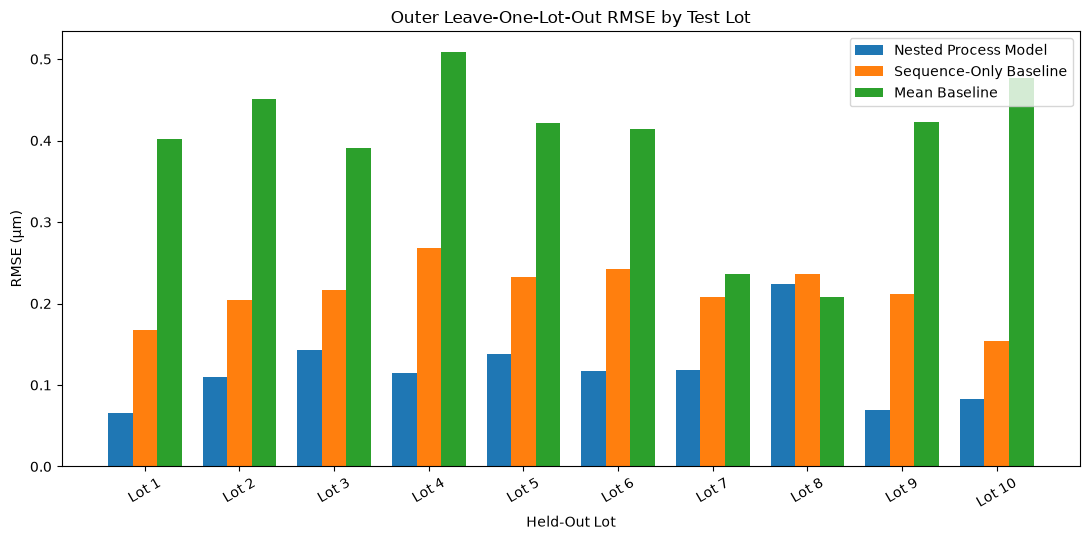

In [8]:
plot_folds = outer_fold_results.sort_values("test_lot").reset_index(drop=True)

x = np.arange(len(plot_folds))
width = 0.26

plt.figure(figsize=(11, 5.5))

plt.bar(
    x - width,
    plot_folds["outer_rmse"],
    width=width,
    label="Nested Process Model",
)

plt.bar(
    x,
    plot_folds["sequence_baseline_rmse"],
    width=width,
    label="Sequence-Only Baseline",
)

plt.bar(
    x + width,
    plot_folds["mean_baseline_rmse"],
    width=width,
    label="Mean Baseline",
)

plt.xticks(
    x,
    [f"Lot {lot}" for lot in plot_folds["test_lot"]],
    rotation=30,
)

plt.ylabel("RMSE (µm)")
plt.xlabel("Held-Out Lot")
plt.title("Outer Leave-One-Lot-Out RMSE by Test Lot")
plt.legend()
plt.tight_layout()
plt.show()


### 6.4 每個 Lot 的 RMSE 圖怎麼看？

圖上大部分藍色 bar 都比另外兩個 baselines 低，和表格的 **9/10 Lots** 結果一致。

其中：

- 最低是 **Lot 1：RMSE = 0.0652 µm**
- 最高是 **Lot 8：RMSE = 0.2238 µm**

Lot 8 的藍色 bar 明顯比其他 Lots 高，而且是唯一沒有同時贏過兩個 baselines 的 Lot。

所以後面的 wafer-level error analysis 和 09 explainability，我會優先看 Lot 8，而不是只盯著 pooled R² = 0.8948。


## 7. 固定 Model Family 後，再做一個 Candidate-Family Comparison

前面的 nested procedure 是「每個 outer fold 都可以自己選最佳 feature set + model + hyperparameters」。

這裡再多做一個比較，固定每個：

`Feature Set × Model Family`

然後只在 inner CV 裡選該 family 的 hyperparameters。

這樣可以比較 Base / Extended + Ridge / ElasticNet / PLS / SVR 各自的 pooled outer OOF performance。

但這張表是 **candidate comparison**。  
如果我看完這張表再挑第一名，第一名的 score 就不能再當作全新的 independent test score。正式 performance 還是以 Section 6 的 nested procedure 為主。


In [9]:
family_combinations = [
    (feature_set, model_name)
    for feature_set in ["Base", "Extended"]
    for model_name in ["Ridge", "ElasticNet", "PLS", "SVR"]
]

family_predictions = {
    f"{feature_set}__{model_name}": np.full(len(y), np.nan)
    for feature_set, model_name in family_combinations
}

family_fold_records = []

for outer_fold, (train_idx, test_idx) in enumerate(outer_splits, start=1):
    test_lot = int(np.unique(groups[test_idx])[0])

    for feature_set, model_name in family_combinations:
        family_inner = (
            inner_candidate_scores.loc[
                (inner_candidate_scores["outer_fold"] == outer_fold)
                & (inner_candidate_scores["feature_set"] == feature_set)
                & (inner_candidate_scores["model"] == model_name)
            ]
            .sort_values("inner_rmse")
            .iloc[0]
        )

        params = json.loads(family_inner["params"])
        estimator = build_estimator(model_name, params)
        estimator.fit(
            X_sets[feature_set][train_idx],
            y[train_idx],
        )

        pred = np.asarray(
            estimator.predict(X_sets[feature_set][test_idx])
        ).reshape(-1)

        family_predictions[f"{feature_set}__{model_name}"][test_idx] = pred

        family_fold_records.append(
            {
                "outer_fold": outer_fold,
                "test_lot": test_lot,
                "feature_set": feature_set,
                "model": model_name,
                "params": family_inner["params"],
                "inner_rmse": family_inner["inner_rmse"],
                "outer_rmse": float(mean_squared_error(y[test_idx], pred) ** 0.5),
                "outer_mae": float(mean_absolute_error(y[test_idx], pred)),
            }
        )

family_fold_results = pd.DataFrame(family_fold_records)

family_summary_records = []

for feature_set, model_name in family_combinations:
    pred = family_predictions[f"{feature_set}__{model_name}"]

    family_summary_records.append(
        {
            "feature_set": feature_set,
            "model": model_name,
            **regression_metrics(y, pred),
        }
    )

family_model_summary = (
    pd.DataFrame(family_summary_records)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(family_model_summary.round(4))


,feature_set,model,rmse,mae,r2
0,Extended,ElasticNet,0.1222,0.0908,0.9065
1,Base,ElasticNet,0.1347,0.1031,0.8864
2,Extended,Ridge,0.1589,0.1171,0.8419
3,Extended,PLS,0.1603,0.1192,0.8391
4,Base,Ridge,0.1635,0.1134,0.8326
5,Base,PLS,0.1864,0.1237,0.7825
6,Base,SVR,0.2130,0.1669,0.7160
7,Extended,SVR,0.2195,0.1781,0.6983


### 7.1 不同 Candidate Families 比起來怎麼樣？

固定 family 後，pooled outer OOF RMSE 最低的是：

1. **Extended + ElasticNet：0.1222 µm**
2. **Base + ElasticNet：0.1347 µm**

兩個 ElasticNet 都排在最前面。

其他 families：

- Extended Ridge：**0.1589**
- Extended PLS：**0.1603**
- Base Ridge：**0.1635**
- Base PLS：**0.1864**
- Base SVR：**0.2130**
- Extended SVR：**0.2195**

這個結果和 outer-fold selection 很一致：ElasticNet 在目前候選模型裡表現最好。

Extended + ElasticNet 比 Base + ElasticNet 的 RMSE 約低 **9.3%**，所以 robust-width family 在這個固定-family comparison 裡看起來有幫助。  
不過前面 outer folds 仍有 4/10 選 Base，因此我會把它寫成「Extended 有整體優勢」，而不是「每一個 Lot 都一定需要 Extended」。


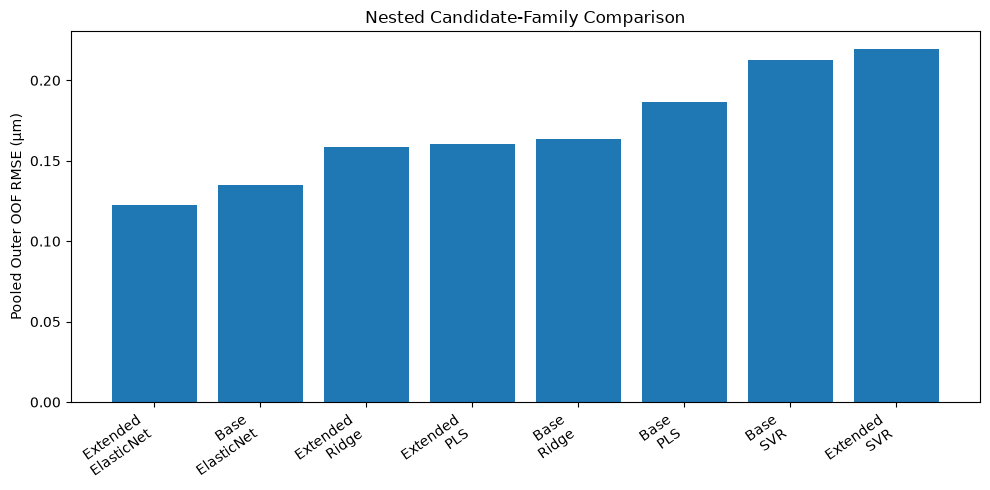

In [10]:
plt.figure(figsize=(10, 5))

plot_family = family_model_summary.copy()
labels = (
    plot_family["feature_set"]
    + "\n"
    + plot_family["model"]
)

plt.bar(
    np.arange(len(plot_family)),
    plot_family["rmse"],
)

plt.xticks(
    np.arange(len(plot_family)),
    labels,
    rotation=35,
    ha="right",
)

plt.ylabel("Pooled Outer OOF RMSE (µm)")
plt.title("Nested Candidate-Family Comparison")
plt.tight_layout()
plt.show()


### 7.2 Family RMSE Bar Chart 怎麼看？

這張圖就是把上一張表畫出來，所以沒有新的統計結論。

最短的是：

- Extended + ElasticNet：**0.1222 µm**

第二短：

- Base + ElasticNet：**0.1347 µm**

Ridge / PLS 在中間，SVR 最高。

圖形讓差距比較直觀，也再次顯示：目前 model-family 的主要優勢來自 ElasticNet；Extended feature set 在 pooled comparison 中又比 Base 再低一些。


## 7.3 看每一片 Wafer 的 Nested OOF Error

Pooled RMSE 只能告訴我平均誤差多大，但不會告訴我「哪一片最難」。

所以這一步把每片 wafer 的：

- actual
- nested OOF prediction
- signed error
- absolute error

都保留下來。

這些 errors **不再拿來選模型**，而是交給 09 做 explainability，也可以和後面的 anomaly / OOD result 做交叉比對。


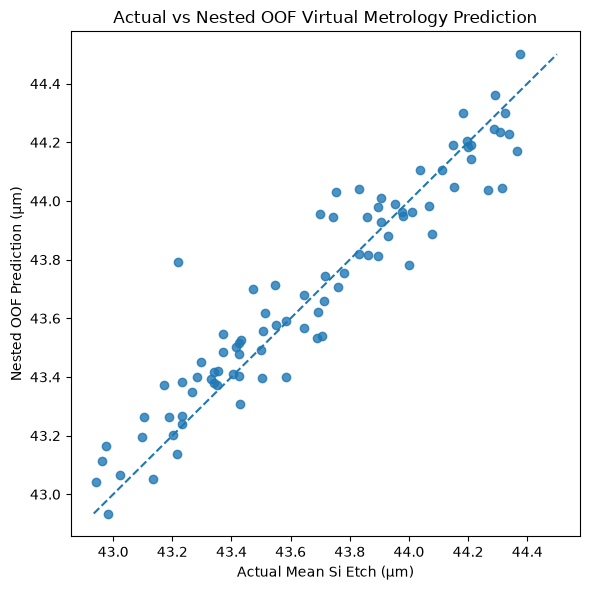

Largest Absolute Nested OOF Errors：


,experiment_key,lot_number,wafer_number,actual_mean_si_etch,nested_process_pred,nested_error,abs_nested_error
74,2024-08-07_10,8,10,43.2175,43.7931,0.5756,0.5756
49,2024-08-01_01,6,1,43.7522,44.0319,0.2796,0.2796
39,2024-07-19_01,5,1,44.3142,44.0441,-0.2701,0.2701
72,2024-08-07_08,8,8,43.6991,43.9566,0.2575,0.2575
21,2024-07-09_03,3,3,44.2660,44.0385,-0.2276,0.2276
73,2024-08-07_09,8,9,43.4738,43.6998,0.2260,0.2260
32,2024-07-11_04,4,4,43.9986,43.7801,-0.2185,0.2185
59,2024-08-05_01,7,1,43.8311,44.0397,0.2086,0.2086
65,2024-08-07_01,8,1,43.7445,43.9465,0.2020,0.2020
46,2024-07-19_08,5,8,43.1721,43.3724,0.2003,0.2003


In [11]:
nested_predictions = pd.DataFrame(
    {
        "experiment_key": experiment_keys,
        "lot_number": groups,
        "wafer_number": wafer_number.astype(int),
        "actual_mean_si_etch": y,
        "mean_baseline_pred": mean_baseline_pred,
        "sequence_baseline_pred": sequence_baseline_pred,
        "nested_process_pred": nested_oof_pred,
    }
)

nested_predictions["nested_error"] = (
    nested_predictions["nested_process_pred"]
    - nested_predictions["actual_mean_si_etch"]
)

nested_predictions["abs_nested_error"] = (
    nested_predictions["nested_error"].abs()
)

plt.figure(figsize=(6, 6))
plt.scatter(
    nested_predictions["actual_mean_si_etch"],
    nested_predictions["nested_process_pred"],
    alpha=0.8,
)

lower = min(
    nested_predictions["actual_mean_si_etch"].min(),
    nested_predictions["nested_process_pred"].min(),
)
upper = max(
    nested_predictions["actual_mean_si_etch"].max(),
    nested_predictions["nested_process_pred"].max(),
)

plt.plot([lower, upper], [lower, upper], linestyle="--")
plt.xlabel("Actual Mean Si Etch (µm)")
plt.ylabel("Nested OOF Prediction (µm)")
plt.title("Actual vs Nested OOF Virtual Metrology Prediction")
plt.tight_layout()
plt.show()

print("Largest Absolute Nested OOF Errors：")
display(
    nested_predictions
    .nlargest(10, "abs_nested_error")
    [
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "actual_mean_si_etch",
            "nested_process_pred",
            "nested_error",
            "abs_nested_error",
        ]
    ]
    .round(4)
)


### 7.4 Wafer-Level Error 怎麼看？

最大 absolute Nested OOF error 是：

**`2024-08-07_10`（Lot 8, Wafer 10）**

- Actual = **43.2175 µm**
- Prediction = **43.7931 µm**
- Error = **+0.5756 µm**

正值代表模型把這片 wafer 的 etch 高估了約 **0.576 µm**。

前 10 大 absolute errors 裡，Lot 8 出現 **4 片**：

- `2024-08-07_10`
- `2024-08-07_08`
- `2024-08-07_09`
- `2024-08-07_01`

這和 Lot 8 的 per-Lot RMSE 最高完全對得上，所以不是只有單一 wafer 剛好失手，Lot 8 整體對「用其他 Lots 訓練的模型」來說確實比較難。

Actual vs Predicted scatter 大多數點貼近 `y=x`，但仍可以看到幾個比較明顯偏離對角線的點。這些點值得後面仔細查，但**prediction error 大不等於 process anomaly**，還要再和 process-side evidence 對照。


## 8. Nested Evaluation 做完後，再建立 Final Prototype Model

前面的 nested outer evaluation 已經先完成，所以現在才使用全部 88 片 labeled wafers 來選一個 final configuration。

這個 final model 的用途是：

- 09 explainability
- prototype / deployment preparation

做法是用全部 10 Lots 的 grouped LOGO CV 比較同一批 36 candidates，選 grouped CV RMSE 最低的 configuration，再用全部 88 片 fit 最後一個 pipeline。

要注意：

> **這裡的 selection score 不是新的 independent test performance。**

因為我已經用全部資料參與 final configuration selection。  
真正要報 generalization 時，還是回到前面的 nested OOF metrics。


In [12]:
full_selection_records = []

for feature_set, model_name, params in candidate_configs:
    full_oof = np.full(len(y), np.nan)
    estimator = build_estimator(model_name, params)

    for train_idx, valid_idx in outer_splits:
        fitted = clone(estimator)
        fitted.fit(
            X_sets[feature_set][train_idx],
            y[train_idx],
        )
        full_oof[valid_idx] = np.asarray(
            fitted.predict(X_sets[feature_set][valid_idx])
        ).reshape(-1)

    full_selection_records.append(
        {
            "feature_set": feature_set,
            "model": model_name,
            "params": json.dumps(params, sort_keys=True),
            "logo_rmse": float(mean_squared_error(y, full_oof) ** 0.5),
        }
    )

full_selection_scores = (
    pd.DataFrame(full_selection_records)
    .sort_values("logo_rmse")
    .reset_index(drop=True)
)

display(full_selection_scores.head(10).round(5))

best_full = full_selection_scores.iloc[0]
final_feature_set = best_full["feature_set"]
final_model_name = best_full["model"]
final_params = json.loads(best_full["params"])

print("Final Feature Set：", final_feature_set)
print("Final Model：", final_model_name)
print("Final Params：", final_params)


,feature_set,model,params,logo_rmse
0,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",0.11121
1,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.11173
2,Extended,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.11869
3,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",0.12930
4,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",0.12997
5,Extended,ElasticNet,"{""alpha"": 0.1, ""l1_ratio"": 0.1}",0.13321
6,Base,Ridge,"{""alpha"": 1}",0.13338
7,Base,ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",0.13644
8,Extended,Ridge,"{""alpha"": 1}",0.13853
9,Extended,Ridge,"{""alpha"": 10}",0.14229


Final Feature Set： Extended
Final Model： ElasticNet
Final Params： {'alpha': 0.01, 'l1_ratio': 0.1}


### 8.1 Final configuration 怎麼選？

全資料 grouped LOGO selection 的前兩名都是 Extended + ElasticNet：

1. `alpha=0.01, l1_ratio=0.1`：RMSE = **0.11121 µm**
2. `alpha=0.01, l1_ratio=0.5`：RMSE = **0.11173 µm**

第一名只比第二名低 **0.00052 µm**。

所以 final prototype 會用第一名：

**Extended + ElasticNet (`alpha=0.01`, `l1_ratio=0.1`)**

但我不會把 `l1_ratio=0.1` 說成被資料「非常明確地選中」，因為它和 0.5 幾乎沒有差。  
這裡只是需要選一個固定 configuration 給 09 用。

正式 internal performance 還是前面的 Nested OOF：

**RMSE = 0.1296 µm**。


In [13]:
final_estimator = build_estimator(final_model_name, final_params)
final_estimator.fit(
    X_sets[final_feature_set],
    y,
)

# Recover the columns retained by the same near-constant rule used in CV.
variance_mask = final_estimator.named_steps["variance"].get_support()
final_kept_features = np.asarray(
    predictor_names[final_feature_set]
)[variance_mask]

final_model = final_estimator.named_steps["model"]

# Only Ridge / ElasticNet have coefficients that can be interpreted directly
# after the explicit StandardScaler step used in this pipeline.
linear_coefficients_available = final_model_name in {"Ridge", "ElasticNet"}

coefficient_columns = [
    "feature",
    "coefficient_standardized",
    "abs_coefficient",
]

if linear_coefficients_available:
    model_coefficients = np.asarray(final_model.coef_, dtype=float).reshape(-1)

    if len(model_coefficients) != len(final_kept_features):
        raise ValueError(
            "Final linear coefficient count 與 variance-filter 後 predictors 不一致"
        )

    final_coefficients = (
        pd.DataFrame(
            {
                "feature": final_kept_features,
                "coefficient_standardized": model_coefficients,
                "abs_coefficient": np.abs(model_coefficients),
            }
        )
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    n_nonzero = int(np.count_nonzero(np.abs(model_coefficients) > 1e-12))
else:
    # Keep a stable schema even when the selected model has no direct
    # standardized linear coefficients (e.g. PLS / RBF-SVR here).
    final_coefficients = pd.DataFrame(columns=coefficient_columns)
    n_nonzero = None

print("Final Training Wafers：", len(y))
print("Final Feature Set：", final_feature_set)
print("Final Model：", final_model_name)
print("Input Predictors：", len(predictor_names[final_feature_set]))
print("Predictors after Near-Constant Filter：", len(final_kept_features))
print("Direct Linear Coefficients Available：", linear_coefficients_available)
print("Non-zero Linear Coefficients：", n_nonzero)

if linear_coefficients_available:
    print("\nTop standardized coefficients — descriptive only：")
    display(final_coefficients.head(15).round(5))
else:
    print(
        "\nSelected model沒有可直接作 standardized additive interpretation 的"
        " Ridge / ElasticNet coefficients；09 將改用 model-agnostic permutation / local sensitivity。"
    )


Final Training Wafers： 88
Final Feature Set： Extended
Final Model： ElasticNet
Input Predictors： 109
Predictors after Near-Constant Filter： 98
Direct Linear Coefficients Available： True
Non-zero Linear Coefficients： 54

Top standardized coefficients — descriptive only：


,feature,coefficient_standardized,abs_coefficient
0,robust_width__PlatenRFTuningCapacitor,0.15959,0.15959
1,mean__PlatenRFTuningCapacitor,-0.10487,0.10487
2,main_active_duration,0.09182,0.09182
3,robust_width__PlatenRFReflectedPower,-0.09083,0.09083
4,std__ForeLinePressure,-0.07588,0.07588
5,mean__Heater2Temp,0.05977,0.05977
6,std__SourceRFReflectedPower,-0.05684,0.05684
7,mean__SourceRFLoadPower,0.04794,0.04794
8,std__SourceRFPeakToPeak,0.04177,0.04177
9,late_minus_early__PlatenRFLoadCapacitor,-0.03816,0.03816


### 8.2 Final Model 實際用了多少 Features？

Final prototype 使用：

- Candidate predictors：**109**
- Near-constant filter 後：**98**
- 被 filter 掉：**11**
- Non-zero ElasticNet coefficients：**54**

也就是說，先由 near-constant filter 拿掉 11 個幾乎沒 variation 的欄位，ElasticNet 再把 98 個裡的一部分 coefficient 壓到 0，最後有 **54 個 non-zero predictors**。

目前 absolute standardized coefficient 最大的是：

- `robust_width__PlatenRFTuningCapacitor`：**+0.15959**
- `mean__PlatenRFTuningCapacitor`：**-0.10487**
- `main_active_duration`：**+0.09182**

這只能先當成 predictive weight 的線索。  
因為很多 engineered features 彼此相關，單一 coefficient 不能直接當成「這個 sensor 的物理因果效果」。09 會再用更完整的方法看 feature / sensor importance 和 local errors。


## 9. 把 Modeling 結果和 Final Pipeline 存下來

最後把這一本需要交給 09 的結果全部輸出：

- baselines
- nested outer-fold results
- inner candidate scores
- nested OOF predictions
- family comparison
- final selection scores
- final coefficients
- final model config
- fitted pipeline

除了寫出檔案，也重新讀回來驗證 row count、schema、JSON 內容和 joblib prediction，避免後面 09 讀到的東西和 08 記憶體裡的結果不一樣。


In [14]:
baseline_metrics_path = PROCESSED_DATA_DIR / "08_baseline_metrics.csv"
outer_results_path = PROCESSED_DATA_DIR / "08_nested_outer_fold_results.csv"
inner_scores_path = PROCESSED_DATA_DIR / "08_nested_inner_candidate_scores.csv"
nested_predictions_path = PROCESSED_DATA_DIR / "08_nested_oof_predictions.csv"
family_summary_path = PROCESSED_DATA_DIR / "08_family_model_summary.csv"
family_fold_path = PROCESSED_DATA_DIR / "08_family_fold_results.csv"
full_selection_path = PROCESSED_DATA_DIR / "08_full_selection_scores.csv"
coefficients_path = PROCESSED_DATA_DIR / "08_final_model_coefficients.csv"
final_config_path = PROCESSED_DATA_DIR / "08_final_model_config.json"
final_model_path = MODEL_DIR / "08_final_virtual_metrology_model.joblib"

baseline_metrics.to_csv(baseline_metrics_path, index=False)
outer_fold_results.to_csv(outer_results_path, index=False)
inner_candidate_scores.to_csv(inner_scores_path, index=False)
nested_predictions.to_csv(nested_predictions_path, index=False)
family_model_summary.to_csv(family_summary_path, index=False)
family_fold_results.to_csv(family_fold_path, index=False)
full_selection_scores.to_csv(full_selection_path, index=False)
final_coefficients.to_csv(coefficients_path, index=False)

final_config = {
    "target": "mean_si_etch",
    "feature_set": final_feature_set,
    "model": final_model_name,
    "params": final_params,
    "n_training_wafers": int(len(y)),
    "n_input_predictors": int(len(predictor_names[final_feature_set])),
    "input_predictors_in_order": list(predictor_names[final_feature_set]),
    "n_predictors_after_variance_filter": int(len(final_kept_features)),
    "predictors_after_variance_filter": final_kept_features.tolist(),
    "linear_coefficients_available": bool(linear_coefficients_available),
    "n_nonzero_coefficients": (int(n_nonzero) if n_nonzero is not None else None),
    "full_data_selection_logo_rmse": float(best_full["logo_rmse"]),
    "primary_evaluation": "Nested Leave-One-Lot-Out outer validation",
    "performance_note": (
        "Use nested outer OOF metrics for internal generalization evidence; "
        "the final full-data fit has no independent test score."
    ),
    "explainability_note": (
        "Direct standardized coefficients are exported only for Ridge / ElasticNet. "
        "Other selected model families require model-agnostic explainability in 09."
    ),
}

with open(final_config_path, "w", encoding="utf-8") as file:
    json.dump(final_config, file, ensure_ascii=False, indent=2)

joblib.dump(final_estimator, final_model_path)

# Read every tabular artifact back and verify row count + schema.
csv_artifacts = {
    baseline_metrics_path: baseline_metrics,
    outer_results_path: outer_fold_results,
    inner_scores_path: inner_candidate_scores,
    nested_predictions_path: nested_predictions,
    family_summary_path: family_model_summary,
    family_fold_path: family_fold_results,
    full_selection_path: full_selection_scores,
    coefficients_path: final_coefficients,
}

validation_records = []
for path, expected_df in csv_artifacts.items():
    reloaded = pd.read_csv(path)
    same_rows = len(reloaded) == len(expected_df)
    same_columns = list(reloaded.columns) == list(expected_df.columns)

    if not same_rows or not same_columns:
        raise ValueError(f"Artifact read-back validation failed: {path.name}")

    validation_records.append(
        {
            "artifact": path.name,
            "rows": len(reloaded),
            "schema_match": same_columns,
        }
    )

with open(final_config_path, "r", encoding="utf-8") as file:
    config_check = json.load(file)
if config_check != final_config:
    raise ValueError("Final config JSON read-back 不一致")

# Reload the fitted pipeline and confirm identical predictions on the 88 labeled wafers.
reloaded_estimator = joblib.load(final_model_path)
original_full_pred = np.asarray(
    final_estimator.predict(X_sets[final_feature_set])
).reshape(-1)
reloaded_full_pred = np.asarray(
    reloaded_estimator.predict(X_sets[final_feature_set])
).reshape(-1)
if not np.allclose(original_full_pred, reloaded_full_pred, rtol=0, atol=1e-12):
    raise ValueError("Reloaded final model predictions 與原 model 不一致")

artifact_validation = pd.DataFrame(validation_records)
print("CSV Read-Back Validation：")
display(artifact_validation)
print("JSON Read-Back：通過")
print("Joblib Prediction Read-Back：通過")


CSV Read-Back Validation：


,artifact,rows,schema_match
0,08_baseline_metrics.csv,2,True
1,08_nested_outer_fold_results.csv,10,True
2,08_nested_inner_candidate_scores.csv,360,True
3,08_nested_oof_predictions.csv,88,True
4,08_family_model_summary.csv,8,True
5,08_family_fold_results.csv,80,True
6,08_full_selection_scores.csv,36,True
7,08_final_model_coefficients.csv,98,True


JSON Read-Back：通過
Joblib Prediction Read-Back：通過


### 9.1 輸出結果有沒有存對？

所有輸出都通過 read-back validation：

- **8 個 CSV**
- **1 個 JSON**
- **1 個 joblib model**

CSV 的 row count 和 schema 都是 `True`；JSON 讀回後內容一致；joblib model 重新載入後，在 88 片 labeled wafers 上的 predictions 也和原本 final estimator 完全一樣。

幾個重要 row count 也對得上：

- Outer-fold results：**10 rows**
- Inner candidate scores：**360 rows = 10 outer folds × 36 candidates**
- Nested OOF predictions：**88 rows**
- Family summary：**8 rows**
- Family fold results：**80 rows = 10 folds × 8 families**
- Full selection scores：**36 rows**
- Final coefficient table：**98 rows**

所以 09 可以直接沿用這些 artifacts，不需要重新跑另一套 08 邏輯。

其中要特別分清楚：

- `08_nested_oof_predictions.csv`：拿來看 held-out-Lot generalization / error
- `08_final_virtual_metrology_model.joblib`：full-data final prototype，用來做 explainability / deployment preparation，不是新的 test score


# 08｜整份 Notebook 的統整結論

這一本真正想知道的是：**process features 在整個 Lot 都沒被模型看過的情況下，還能不能預測 `mean_si_etch`？**

我用 88 片 labeled wafers、10 個 Lots 做 nested group-aware validation。每次 outer loop 都完整留一個 Lot 當 test，near-constant filtering、scaling、feature-set selection、model selection 和 hyperparameter selection 都只在 training Lots 裡完成。

先看 baseline，Training-Mean 的 RMSE 是 **0.4044 µm**，而只用 `wafer_number` 的 Sequence-only baseline 已經可以做到 **0.2209 µm**。這代表 wafer sequence 本身就有很強的 predictive structure，所以 process model 如果只比 mean baseline 好，其實還不夠有說服力。

正式 nested OOF 的結果是：

- RMSE：**0.1296 µm**
- MAE：**0.0972 µm**
- R²：**0.8948**

在相同 held-out-Lot evaluation 下，它的 RMSE 比 mean baseline 低約 **68.0%**，也比 sequence-only baseline 低約 **41.3%**。10 個 held-out Lots 中有 **9/10** 同時低於兩個 baselines。

不過泛化不是每個 Lot 都一樣。**Lot 8 是最明顯的弱點**，RMSE = **0.2238 µm**，而且前 10 大 wafer-level absolute errors 裡有 4 片來自 Lot 8。最大單片 error 是 `2024-08-07_10`，模型高估 **0.5756 µm**。所以只報 pooled R² 會漏掉這個重要問題。

Model selection 的部分也有一個很清楚的 pattern：**10/10 outer folds 都選到 ElasticNet**。Feature set 則比較沒那麼絕對，Extended 被選 6 次、Base 4 次。固定 family 比較時，Extended + ElasticNet 的 pooled OOF RMSE 最低，為 **0.1222 µm**，Base + ElasticNet 第二，為 **0.1347 µm**。

在 nested evaluation 完成後，我才用全部 88 片資料選 final prototype。最後選的是：

**Extended + ElasticNet (`alpha=0.01`, `l1_ratio=0.1`)**

但它和第二名 `l1_ratio=0.5` 只差 **0.00052 µm**，所以這個精確 hyperparameter 不能解讀得太重。Final pipeline 從 109 個 candidate predictors 經 near-constant filter 留下 98 個，ElasticNet 最後有 **54 個 non-zero coefficients**。

因此 08 可以支持的結論是：

> **在目前 10 個 Lots 的 nested held-out-Lot validation 中，process-feature Virtual Metrology model 對 `mean_si_etch` 有很好的 internal generalization，並且在相同 evaluation 下明顯低於簡單的 mean 與 sequence-only baselines。**

但我不會把它直接寫成「已證明未來所有 production Lots 都能維持同樣表現」，也不會說「process features 已被證明提供完全獨立於 wafer sequence 的因果資訊」。這份結果仍然是目前資料範圍內的 internal validation。

下一本 09 最重要的兩件事就是：

1. 看 final ElasticNet 到底主要依賴哪些 process features / sensors；
2. 特別檢查 Lot 8 和 `2024-08-07_10` 這些高 error cases，確認模型錯在哪裡，而不是只停在一個漂亮的 pooled score。
